# Used Car Price Prediction

## 1) Problem statement.

* This dataset comprises used cars sold on cardehko.com in India as well as important features of these cars.
* If user can predict the price of the car based on input features.
* Prediction results can be used to give new seller the price suggestion based on market condition.

## 2) Data Collection.
* The Dataset is collected from scrapping from cardheko webiste
* The data consists of 13 column and 15411 rows.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [84]:
df = pd.read_csv('cardekho_imputated.csv',index_col=[0])
df

FileNotFoundError: [Errno 2] No such file or directory: 'cardekho_imputated.csv'

## Data Cleaning
### Handling Missing values

* Handling Missing values 
* Handling Duplicates
* Check data type
* Understand the dataset


In [ ]:
df.isnull().sum() # no missing values all good

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [ ]:
df.model.unique()


array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

In [ ]:
len(df.model.unique()) 

# 120 unique model is present in the car model 

120

In [ ]:
len(df.car_name.unique())

121

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [ ]:
df.drop(['car_name','brand'],axis =1,inplace=True)

# Feature Extraction


In [ ]:
num_features =[f for f in  df.columns if df[f].dtype != "O"]
print('num_fea: ',len(num_features))

cat_features =[f for f in  df.columns if df[f].dtype == "O"]
print('cat_fea: ',len(cat_features))

dis_features =[f for f in  num_features if len(df[f].unique()) <= 25]
print('dis_fea: ',len(dis_features))

cont_features =[f for f in  num_features if len(df[f].unique()) > 25]
print('cont_fea: ',len(cont_features))

num_fea:  7
cat_fea:  4
dis_fea:  2
cont_fea:  5


In [ ]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# target segragation

In [ ]:
## Indpendent and dependent features
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['model'] =le.fit_transform(X['model'])


In [ ]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((12328, 10), (3083, 10))

## Feature Encoding and Scaling
**One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

In [ ]:
cat_features

['model', 'seller_type', 'fuel_type', 'transmission_type']

In [ ]:
len(df['model'].unique()),len(df['seller_type'].unique()),len(df['fuel_type'].unique()),len(df['transmission_type'].unique())

(120, 3, 5, 2)

#### labelencoder for car_name as it has large number of categories
#### Onehot Encoder for other having less number of categories

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler

one_hot_col=[f for f in cat_features if len(df[f].unique()) <= 5]
num_features.remove('selling_price')

preprocessor =ColumnTransformer(
    [
        ("OneHotEncoder",OneHotEncoder(drop='first'),one_hot_col),
        ("StandardScaler", StandardScaler(), num_features)
    ],remainder= "passthrough"
)



🧠 Why?

LabelEncoder works on 1D target (y)

ColumnTransformer sends 2D feature matrix (X)

👉 mismatch →  error (the one you saw earlier)

In [ ]:
label_col =[f for f in  cat_features if f not in one_hot_col]

label_col  

['model']

In [ ]:
one_hot_col

['seller_type', 'fuel_type', 'transmission_type']

In [ ]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
pd.DataFrame(X)

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,7,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,54,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,118,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,7,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,38,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5
...,...,...,...,...,...,...,...,...,...,...
19537,117,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5
19540,42,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7
19541,77,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5
19542,114,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7


In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [ ]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,108.0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,91.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,17.0
3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,25.0
4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,117.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12323,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.323969,1.702310,0.248161,-0.453086,-0.270460,2.070500,42.0
12324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.653383,0.084198,-0.876105,0.218310,0.066393,-0.403824,95.0
12325,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.323969,-0.833967,0.185702,-0.932654,-0.779483,-0.403824,100.0
12326,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.337798,-0.951680,-0.273133,-0.550917,-0.432805,-0.403824,118.0


In [ ]:
X_train

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         2.68168531e+00, -4.03823711e-01,  1.08000000e+02],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.82744356e-01, -4.03823711e-01,  9.10000000e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         3.29691050e+00, -4.03823711e-01,  1.70000000e+01],
       ...,
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -7.79482730e-01, -4.03823711e-01,  1.00000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -4.32804504e-01, -4.03823711e-01,  1.18000000e+02],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         6.75630567e-02, -4.03823711e-01,  2.40000000e+01]])

In [ ]:
X_test

array([[  0.        ,   0.        ,   0.        , ...,  -0.50204658,
         -0.40382371, 117.        ],
       [  1.        ,   0.        ,   1.        , ...,  -0.61667028,
         -0.40382371,  13.        ],
       [  0.        ,   0.        ,   1.        , ...,  -0.27139561,
          2.0704997 ,  42.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,  -0.27279917,
         -0.40382371,  10.        ],
       [  1.        ,   0.        ,   0.        , ...,  -0.77948273,
         -0.40382371, 100.        ],
       [  0.        ,   0.        ,   1.        , ...,  -0.27209739,
         -0.40382371, 118.        ]])

## Model Training And Model Selection

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# create a function to evalute model
from sklearn.metrics import  mean_absolute_error,root_mean_squared_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.metrics import r2_score

def evalute_regression_model(actual,predicted):
    mae = mean_absolute_error(actual,predicted)
    mse = mean_squared_error(actual,predicted)
    rmse = root_mean_squared_error(actual,predicted)
    r2score= r2_score(actual,predicted)
    mae_percentage = mean_absolute_percentage_error(actual,predicted)
    return mae,mse,rmse,r2score,mae_percentage

## Model Training

In [ ]:
models = {
    'Linear Regression' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    "ElasticNet" :ElasticNet(),
    'K-NN Regressor' : KNeighborsRegressor(),
    'Decision Tree Regressor' : DecisionTreeRegressor(),
    'Random Forest Regressor' : RandomForestRegressor()
 }


for m in range(len(list(models))):
    model = list(models.values())[m]
    
    model.fit(X_train,y_train) # model training

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evalute Train and Test dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2_score,model_train_mae_percentage = evalute_regression_model(y_train,y_train_pred)

    model_test_mae , model_test_mse,  model_test_rmse, model_test_r2_score, model_test_mae_percentage= evalute_regression_model(y_test, y_test_pred)
       
    print(list(models.keys())[m])
    
    print('Model performance for Training set')
    print("- Mean Squared Error : {:.4f}".format(model_train_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2_score))
    print("- Mean Absolute Percentage Error: {:.4f}".format(model_train_mae_percentage))


    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Mean Squared Error : {:.4f}".format(model_test_mse))
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2_score))
    print("- Mean Absolute Percentage Error: {:.4f}".format(model_test_mae_percentage))


    print('='*35)
    print('\n')
# Your errors look big numerically, but they are reasonable for the problem

Linear Regression
Model performance for Training set
- Mean Squared Error : 306756099359.7596
- Root Mean Squared Error: 553855.6665
- Mean Absolute Error: 268101.6071
- R2 Score: 0.6218
- Mean Absolute Percentage Error: 0.5152
----------------------------------
Model performance for Test set
- Mean Squared Error : 252550062888.5633
- Root Mean Squared Error: 502543.5930
- Mean Absolute Error: 279618.5794
- R2 Score: 0.6645
- Mean Absolute Percentage Error: 0.5334


Lasso
Model performance for Training set
- Mean Squared Error : 306756104246.3314
- Root Mean Squared Error: 553855.6710
- Mean Absolute Error: 268099.3255
- R2 Score: 0.6218
- Mean Absolute Percentage Error: 0.5152
----------------------------------
Model performance for Test set
- Mean Squared Error : 252549244113.0731
- Root Mean Squared Error: 502542.7784
- Mean Absolute Error: 279614.8515
- R2 Score: 0.6645
- Mean Absolute Percentage Error: 0.5334


Ridge
Model performance for Training set
- Mean Squared Error : 306756

In [ ]:
y.mean(),y.median()

# mean > median
# that means right skewed data

(np.float64(774971.1164103562), 556000.0)

<Axes: xlabel='selling_price', ylabel='Count'>

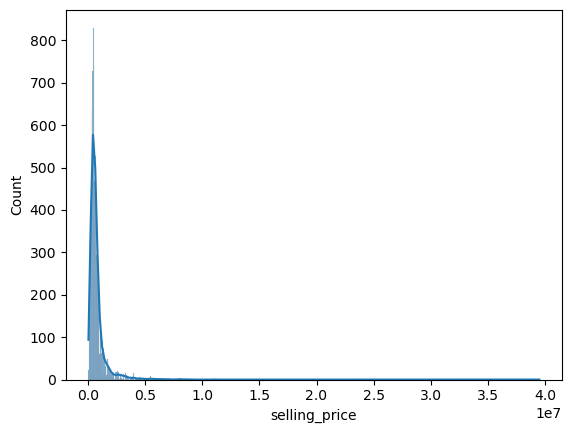

In [ ]:
import seaborn as sns

sns.histplot(y_train, kde=True)
# sns.histplot(np.log1p(y_train), kde=True)

This plot is **very important** — it confirms everything we discussed earlier.

---

# 🧠 🔍 What your KDE plot shows

* Massive spike near **low values**
* Long tail extending to **very high prices**
* Distribution is **heavily right-skewed**

👉 In simple words:

> Most cars are cheap, but a few are very expensive

---

# 🚨 Why this is a problem

## 1. Model bias toward high values

* Expensive cars dominate error
* RMSE becomes large
* Model struggles to generalize

---

## 2. Linear models fail (confirmed)

This shape is:

```text
NOT normal ❌
NOT linear ❌
```

👉 That’s why:

* Linear Regression → 53% error
* Tree models → much better

---

# 🔥 This plot is screaming one thing:

> 👉 **USE LOG TRANSFORM**

---

# 🚀 What happens after log transform

### BEFORE (your plot)

* Skewed ❌
* Long tail ❌

### AFTER log(y)

* More symmetric ✅
* Easier to learn ✅
* Less impact of outliers ✅

---

# 🧪 Do this NOW (visual proof)

```python
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(y_train)
plt.title("Before Log")

plt.subplot(1,2,2)
sns.kdeplot(np.log1p(y_train))
plt.title("After Log")

plt.show()
```

---

# 🧠 Expected result

| Before        | After         |
| ------------- | ------------- |
| Highly skewed | Nearly normal |
| Hard to model | Easy to model |

---

# 📉 Impact on your model

After log transform:

* RMSE ↓ significantly
* MAPE ↓ (especially for expensive cars)
* R² ↑ slightly

---

# 🎯 Why this works (core intuition)

Instead of learning:

```text
₹1L → ₹10L (huge gap)
```

Model learns:

```text
log(1L) → log(10L) (compressed gap)
```

👉 Makes relationships smoother

---

# ⚠️ One more thing (advanced insight)

Your dataset likely has:

* Outliers (luxury cars)
* Mixed distributions (economy + premium)

👉 Log transform helps unify them

---

# 🏆 Final Takeaway

> This plot proves your problem is **skewed → non-linear → requires transformation**

---

# 🚀 What I recommend now

Do this pipeline:

```text
Log Transform → Random Forest / XGBoost → Evaluate
```

---

# 🚀 If you want next level

I can:
👉 Show **before vs after metrics using your exact data**
👉 Or help you push model to **<10% MAPE with XGBoost**

Just say:
👉 **“apply log + compare results”**


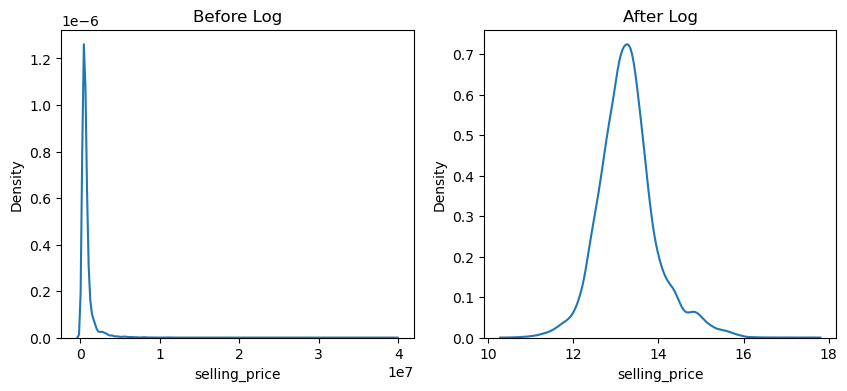

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(y_train)
plt.title("Before Log")

plt.subplot(1,2,2)
sns.kdeplot(np.log1p(y_train))
plt.title("After Log")

plt.show()

# apply log transform


| Model Type        | Log Transform Impact    |
| ----------------- | ----------------------- |
| Linear Regression | 🔥 Huge improvement     |
| Random Forest     | ⚠️ Small improvement    |
| XGBoost           | 🔥 Moderate improvement |


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

# Initialize model (you can replace with your tuned model)
model = RandomForestRegressor(n_estimators=200, random_state=42)

# ===== LOG TRANSFORM =====
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ===== TRAIN =====
model.fit(X_train, y_train_log)

# ===== PREDICT =====
y_pred_log = model.predict(X_test)

# ===== INVERSE TRANSFORM =====
y_pred = np.expm1(y_pred_log)

# ===== EVALUATION =====
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# ===== PRINT RESULTS =====
print("After Log Transform (Random Forest)")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")

After Log Transform (Random Forest)
MAE  : 100112.73
RMSE : 226927.19
R2   : 0.9316
MAPE : 0.1347


# Want remove large value dominance in mse ,rmse,mae

In [ ]:
# # #  Log Transform (VERY POWERFUL) or use Xg boost

# import numpy as np

# y_train_log = np.log1p(y_train)
# y_test_log = np.log1p(y_test)

# model.fit(X_train, y_train_log)

# y_pred = np.expm1(model.predict(X_test))


# # # Reduces large-value dominance
# # # Improves accuracy reduce remse

In [ ]:
model.feature_importances_

array([2.83859957e-03, 2.07114030e-05, 1.16071762e-03, 4.20519576e-06,
       1.17166858e-06, 1.25944563e-03, 2.03531644e-03, 1.29237835e-01,
       6.08283530e-02, 6.21790030e-02, 4.36007361e-02, 6.73305884e-01,
       2.47313312e-03, 2.10548874e-02])

In [ ]:
model

RandomForestRegressor()

Good — now we can **judge your model properly (this is the right way)** 👇

---

# 🧠 Your data distribution

* **Mean = ₹7.7 lakh**
* **Median = ₹5.56 lakh**

👉 This tells us:

> 🔥 Data is **right-skewed (positively skewed)**
> (few expensive cars pulling the mean up)

---

# 📊 Now interpret your error correctly

Your model (Random Forest):

* **MAE ≈ ₹1 lakh**
* **RMSE ≈ ₹2.2–2.3 lakh**

---

# 🎯 1. MAE vs Median (BEST way)

[
\frac{1,00,000}{5,56,000} ≈ 18%
]

👉 Interpretation:

> On average, predictions are off by **~18%**

---

# 🎯 2. RMSE vs Mean

[
\frac{2,30,000}{7,70,000} ≈ 30%
]

👉 Interpretation:

> Large errors exist (outliers)

---

# 🧠 What this tells us

## ✅ Your model is GOOD

* R² ≈ **0.93** → strong
* MAE ≈ **18%** → acceptable

---

## ⚠️ But not perfect

* RMSE high → some bad predictions
* Caused by:

  * expensive cars
  * skewed distribution

---

# 🔥 Key Insight (IMPORTANT)

> Mean ≠ Median → data is skewed → RMSE becomes large

---

# 🚀 What you should do NEXT

---

## 🔧 1. Log Transform (MOST IMPORTANT FOR YOU)

Since data is skewed:

```python id="p9f3h7"
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model.fit(X_train, y_train_log)

y_pred = np.expm1(model.predict(X_test))
```

👉 This will:

* Reduce skewness
* Improve accuracy
* Lower RMSE

---

## 🔧 2. Evaluate with percentage metric (BETTER)

```python id="q3x9o2"
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
```

👉 You’ll get:

```text id="t9l2v4"
~0.15–0.20 → 15–20%
```

---

## 🔧 3. Analyze outliers

```python id="9i4z1p"
df['selling_price'].describe()
```

👉 Check:

* max values
* extreme cars

---

# 🧠 Final Interpretation (INTERVIEW LEVEL)

> The dataset is positively skewed (mean > median), which leads to higher RMSE due to large errors on high-value cars. However, MAE indicates the model performs reasonably well with ~15–20% average error.

---

# 🎯 Final Verdict

| Metric      | Meaning          |
| ----------- | ---------------- |
| MAE (~18%)  | Good             |
| RMSE (~30%) | Outliers present |
| R² (~0.93)  | Strong model     |

---

# 🚀 If you want next level

I can:
👉 Show **how log transform improves your metrics instantly (before vs after)**
👉 Or help you reduce error to **<15% MAE**

Just say:
👉 **“optimize model further”**
 
 